# 🚀 **High‑Frequency Crypto Market Notebook**


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv("/kaggle/input/crypto-market-snapshot/coin_markets_hourly_2.csv", parse_dates=["timestamp"])
df.set_index("timestamp", inplace=True)

print(f"✅ Loaded {len(df):,} rows for {df['id'].nunique():,} unique coins")
df.head()

✅ Loaded 72,750 rows for 251 unique coins


,id,symbol,name,current_price,market_cap,total_volume,high_24h,low_24h,price_change_percentage_24h
timestamp,,,,,,,,,
2025-06-20 06:58:22.131159,bitcoin,btc,Bitcoin,104706.000000,2081684601712,1.717044e+10,105036.00,104004.000000,-0.02060
2025-06-20 06:58:22.131159,ethereum,eth,Ethereum,2520.490000,304266601566,1.015969e+10,2541.60,2488.630000,0.05965
2025-06-20 06:58:22.131159,tether,usdt,Tether,0.999986,155869415763,1.448986e+10,1.00,0.999953,-0.01399
2025-06-20 06:58:22.131159,ripple,xrp,XRP,2.150000,126493355757,1.394608e+09,2.18,2.140000,-0.46193
2025-06-20 06:58:22.131159,binancecoin,bnb,BNB,644.830000,94072819826,5.041818e+08,645.72,638.780000,0.01367


 # 🔹 2.1 Top 10 Coins by Average Price

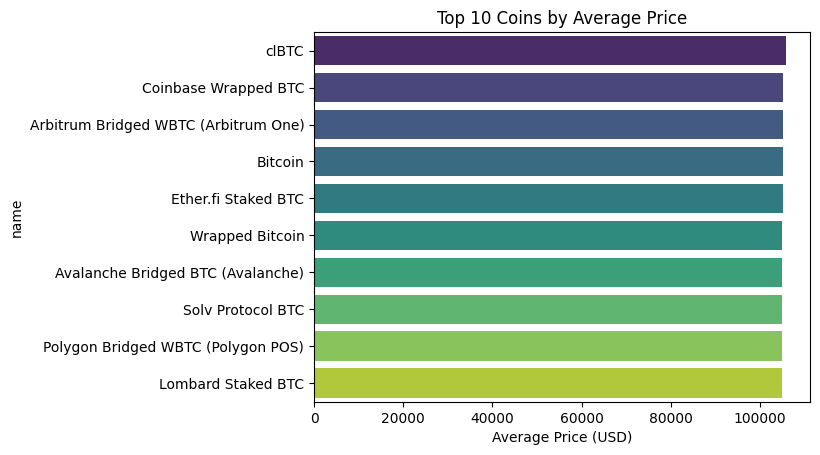

In [4]:
top10 = df.groupby("name")["current_price"].mean().nlargest(10)
sns.barplot(x=top10.values, y=top10.index, palette="viridis")
plt.title("Top 10 Coins by Average Price")
plt.xlabel("Average Price (USD)")
plt.show()


# 🔹 **2.2 Bitcoin Price Trend**

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


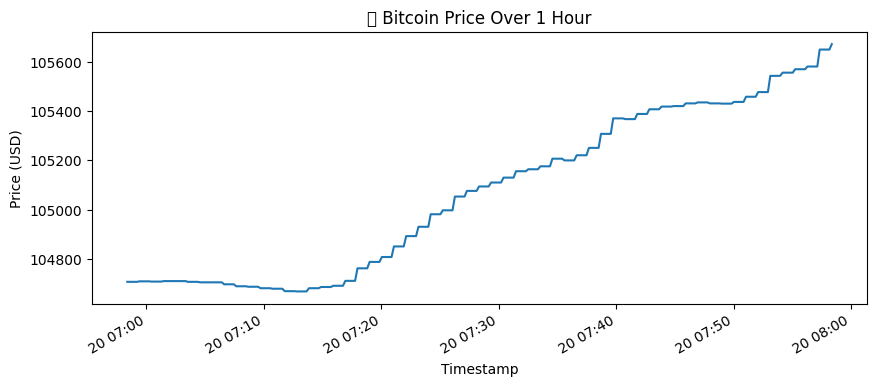

In [5]:
btc = df[df["id"] == "bitcoin"]["current_price"]
btc.plot(figsize=(10, 4), title="📈 Bitcoin Price Over 1 Hour")
plt.xlabel("Timestamp")
plt.ylabel("Price (USD)")
plt.show()


# 🔹 **2.3 Ethereum Volume vs 24h Price Change**

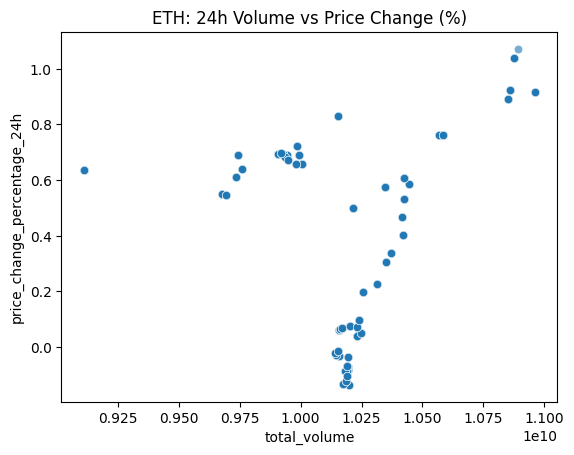

In [6]:
eth = df[df["id"] == "ethereum"]
sns.scatterplot(x="total_volume", y="price_change_percentage_24h", data=eth, alpha=0.6)
plt.title("ETH: 24h Volume vs Price Change (%)")
plt.show()


# 🔹 **3.1 5-Min Rolling Average (BTC)**

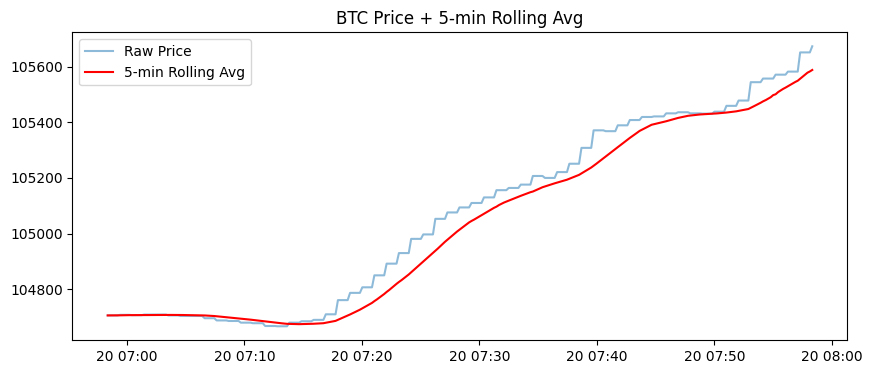

In [7]:
btc_rolling = btc.rolling("5min").mean()
plt.figure(figsize=(10, 4))
plt.plot(btc, alpha=0.5, label="Raw Price")
plt.plot(btc_rolling, color="red", label="5-min Rolling Avg")
plt.legend()
plt.title("BTC Price + 5-min Rolling Avg")
plt.show()


# **🔹 3.2 Rolling Volatility for Several Coins**

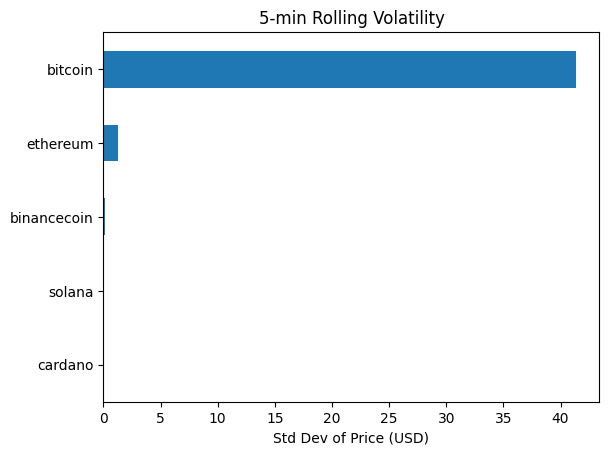

In [8]:
coins = ["bitcoin", "ethereum", "cardano", "solana", "binancecoin"]
vol_dict = {}
for c in coins:
    series = df[df["id"] == c]["current_price"].rolling("5min").std()
    vol_dict[c] = series.iloc[-1]
pd.Series(vol_dict).sort_values().plot(kind="barh", title="5-min Rolling Volatility")
plt.xlabel("Std Dev of Price (USD)")
plt.show()


# **🔹 4.1 Anomaly Detection in BTC**

/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater
  return op(a, b)


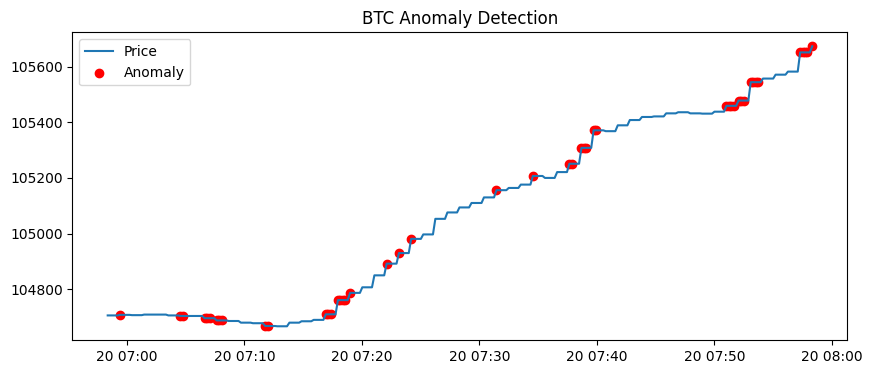

In [10]:
btc_df = df[df["id"] == "bitcoin"].copy()
btc_df["rolling_mean"] = btc_df["current_price"].rolling("5min").mean()
btc_df["rolling_std"] = btc_df["current_price"].rolling("5min").std()
btc_df["anomaly"] = abs(btc_df["current_price"] - btc_df["rolling_mean"]) > 2 * btc_df["rolling_std"]

plt.figure(figsize=(10, 4))
plt.plot(btc_df["current_price"], label="Price")
plt.scatter(btc_df.index[btc_df["anomaly"]], btc_df["current_price"][btc_df["anomaly"]], 
            color="red", label="Anomaly")
plt.legend()
plt.title("BTC Anomaly Detection")
plt.show()


# **🔹 4.2 ARIMA-Based Forecast (Bitcoin)**

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/p

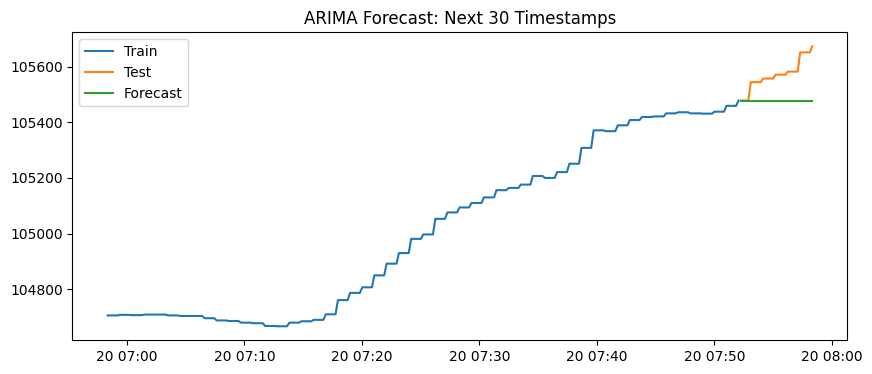

In [11]:
from statsmodels.tsa.arima.model import ARIMA

train = btc_df["current_price"][:-30]
test = btc_df["current_price"][-30:]

model = ARIMA(train, order=(2,1,1)).fit()
forecast = model.forecast(steps=30)

plt.figure(figsize=(10, 4))
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Test")
plt.plot(test.index, forecast, label="Forecast")
plt.legend()
plt.title("ARIMA Forecast: Next 30 Timestamps")
plt.show()


# **🔹 4.3 Hourly Performance Leaderboard**

In [12]:
start_prices = df.groupby("id")["current_price"].first()
end_prices = df.groupby("id")["current_price"].last()
perf = ((end_prices - start_prices) / start_prices * 100).nlargest(10)
print("🏆 Top 10 Gainers (% over the hour):")
print(perf)


🏆 Top 10 Gainers (% over the hour):
id
keeta                      8.144858
virtual-protocol           4.216867
dog-go-to-the-moon-rune    4.157398
eigenlayer                 3.389831
fartcoin                   3.254438
uniswap                    3.170410
curve-dao-token            3.151783
based-brett                3.070671
popcat                     2.967799
bittensor                  2.809038
Name: current_price, dtype: float64


# 🌟 10-Challenge Roadmap: Explore, Analyze, and Forecast Crypto Data

1. **📊 Plot Real-Time Price Trends**  
   - Visualize price movements for **Bitcoin** and **Ethereum** over the full hour—spot patterns, spikes, or dips.

2. **🏅 Top Performers**  
   - Identify the **top 10 gainers and losers** (by % change) among the top 250 coins during the session.

3. **🔄 Rolling Stats**  
   - Calculate and plot **5‑minute rolling averages and volatility** for BTC, ETH, and SOL to explore price stability.

4. **🤝 Correlation Map**  
   - Resample price change data to 1-minute intervals and build a **correlation heatmap** for the top 20 coins.

5. **🚨 Anomaly Detection**  
   - Flag snapshots where a coin’s price deviates beyond **±2× rolling standard deviation**—spot outliers visually on the chart.

6. **📈 Tag-Along Strategy Simulation**  
   - Implement a simplistic rule: e.g., "buy when price drops 1% in 5 minutes, sell when rises 1%"—simulate and tally profit for BTC.

7. **📉 ARIMA Forecasting**  
   - Use an **ARIMA model** on Bitcoin’s time series to forecast the next 30 ticks and evaluate performance.

8. **🧠 LSTM Price Predictor**  
   - Build an **LSTM neural model** to predict the next price for BTC or ETH—benchmark against ARIMA accuracy :contentReference[oaicite:1]{index=1}.

9. **📚 Sentiment Overlay**  
   - Integrate external sources (e.g., Twitter sentiment, Fear & Greed Index), align with snapshot timestamps, and analyze their impact on price.

10. **📊 Build an Interactive Dashboard**  
    - Use **Streamlit or Plotly Dash** to create a real-time dashboard showing live price trends, anomalies, and forecast signals.

---

### 🧭 Suggested Progression
- Begin with **Tasks 1–3** if you're new to time series or Pandas.
- Move to **Tasks 4–6** for intermediate analysis and trading logic.
- Focus on **Tasks 7–10** to dive into advanced forecasting, ML, and interactive apps.



<p align="center" style="font-size:18px; font-weight:900; color:#007A87;">
  <em>
    If you find this notebook and Dataset helpful, please consider 👉 
    <span style="color:#FF8000; font-weight:900; font-size:20px; text-shadow: 0px 0px 2px #FFA500;">
      upvoting ⭐
    </span> 
    to support my work!
  </em>
</p>
